### Purpose of this notebook

- load existing layers diagnostics for J terms
- try to create these manually using the output diagnostics
- should be somewhat similar to the layers output (we hope)

In [1]:
# import the packages and functions, define the directories for the ASTE90 grid
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"


(450, 90)
RAC2d (40500,)
(100,)


In [2]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [3]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1

# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

landmsk = np.zeros((ny,nx))
landmsk[hf1 == 0] = 1
landmsk[hf1 == 1] = np.nan

In [4]:
layers_path

'/scratch3/atnguyen/aste_90x150x60/run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/'

In [5]:
# # define mymsk for a single column and try again

# mymsk = np.full((ny,nx),np.nan)
# mymsk[145,54] = 1

In [6]:
# ok we defined mymsk, now we need to define the indices in ind where these are selected
# load the JtermsT from the function (see previous configuration of layers)

# not sure if this will be the correct way to load it but we can check
# we will use the bins from the An run so that we have the same thing in both sections
# Paths for the bins in this run
filename = "layers2TH"
boundsT = rdmds(layers_path + filename)
binsTH_edges = boundsT.reshape(boundsT.shape[0])
binsTH_centers = (binsTH_edges[:-1] + binsTH_edges[1:])/2
nT = binsTH_edges.shape[0]-1
print(nT)

filename = "layers1SLT"
boundsS = rdmds(layers_path + filename)
binsSLT_edges = boundsS.reshape(boundsS.shape[0])
binsSLT_centers = (binsSLT_edges[:-1] + binsSLT_edges[1:])/2
nS = binsSLT_edges.shape[0]-1
print(nS)

binwidthT = binsTH_edges[1:] - binsTH_edges[:-1]
print(binwidthT.shape)
binwidthS = binsSLT_edges[1:] - binsSLT_edges[:-1]

binwidthT1 = (binwidthT[:-1] + binwidthT[1:])/2
binwidthS1 = (binwidthS[:-1] + binwidthS[1:])/2

dT,dS = np.meshgrid(binwidthT,binwidthS)
dT = dT.reshape(112,112,1)
dS = dS.reshape(112,112,1)

binmidT = ((boundsT[:-1] + boundsT[1:])/2).reshape(nT)
binmidS = ((boundsS[:-1] + boundsS[1:])/2).reshape(nT)

binmidTp = boundsT[1:-1]
binmidSp = boundsS[1:-1]

Tbin,Sbin = np.meshgrid(binsTH_edges,binsSLT_edges)
Tbincent,Sbincent = np.meshgrid(binsTH_centers,binsSLT_centers)
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp)

112
112
(112,)


In [7]:
# get the indices
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
print(ind.shape)
orig_shape = (ind.shape)
orig_shape = (ind.shape)
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))

iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

(40500,)


In [8]:
# load the ifldT terms we need from the THETA field
# we are copying from Jy terms

# setTS_Ttend = ['LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS', 'LTto_TS']

# check these from the miniaste if same order
setTS_Ttend=parsemeta(dirlayers + "layers_TSjoint_Ttend_set1.0000000003.meta")["fldList"]
setTS_Ttend

setTS_Stend=parsemeta(dirlayers + "layers_TSjoint_Stend_set1.0000000003.meta")["fldList"]
setTS_Stend

['LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS', 'LSto_TS']

In [9]:
# great, now copy over, make sure we're using the right function (see previous J term configuration)
# loading G: crios_backups/ASTE_270/Pemberton_BarentsSpaper/Fullstory_BS_postOct1/ASTE_90_calc/wmt_budget_spelloutsaltGOOD.ipynb
# loading J: crios_backups/ASTE_270/Pemberton_BarentsSpaper/presentation_fall_2025/lookatlayers_TS_2007.ipynb
tsstr = np.array(["0000000003","0000000004"])

In [10]:
# do the Jy term
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
# JUST FOR SET1 HERE - NOT FOR SET 2
# 287 - should be indexing nt, ns, wetpoints
# T, S, wetpoints
Jy = {}
nbasin = "BarentsS"
# set each basin to its own dictionary
Jy[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)
small = rac2d * hf2d

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jy[nbasin][t] = {}
    Jy[nbasin][t]['G_T'] = {}
    
    # now loop through the terms and add these to the dictionary
    for i in range(len(setTS_Ttend)-1, -1, -1):
        print(i)
        # read the file and apply masking
        filename = dirlayers + f"layers_TSjoint_Ttend_set1.{t}.data"  # check this with new layers dir
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        # if at end of loop
        if i == len(setTS_Ttend)-1:
            f = (np.nansum(tmp, axis=2))
            f = np.nansum(f * binwidthS1)
    
        # double check the names in the listed file
        if i == len(setTS_Ttend)-1:
            # do not remove from the residual - this is the total tendency
            residT = tmp
        elif i in {0,1,2,3,4}:
            # LaTs_TS LaTh_TS LaTz_TS LTha_TS LTza_TS (LTBh_TS)
            # surface forcing, hDiff, vDiff, hADV, vADV, hADV bolus
            residT -= tmp
    
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # SUM OVER WET POINTS - should be of shape nS-1, nT-1
        # TEST:
        # tmp1 = tmp1.T
        tmp2 = np.nansum(tmp1 * binwidthS1,axis=1)              # SUM OVER S - should be of shape nT-1
        Jy[nbasin][t][setTS_Ttend[i]] = tmp1
        Jy[nbasin][t]['G_T'][setTS_Ttend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2


    myresid = np.nansum(residT[:,:,iwet_mine],axis=2)    # SUM OVER WET POINTS - should be of shape nS-1, nT-1
    # myresid = myresid.T
    Jy[nbasin][t]["residT"] = myresid
    Jy[nbasin][t]["G_T"]["residT"] = np.nansum(Jy[nbasin][t]["residT"] * binwidthS1,axis=1)   #SUM OVER S - should be of shape nT-1

    print()
# set units and labels
Jy["unit"] = "m/s/psu"

# # Define your filename
filename = "Jy_miniaste_BarentsS.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

# # Save the dictionary
np.savez(matpath + filename, **Jy)

0000000004
5



KeyboardInterrupt



In [11]:
# we should be able to check if Jy is the same as the JtermsT (I think it should be JtermsT).

### create JtermsT as you normally would here

In [12]:
# we need to first get the THETA and SALT for the basin, then all the terms
# can use the functions we made in create_aste90_layers.py
from create_aste90_layers import create_layers_totalTHETA

In [13]:
dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)

In [14]:
# termsT3D should now be binned to T and S based on the basin at tsstr[1]
# let's load these values

In [15]:
termsT3D.keys()

dict_keys(['ADVh', 'ADVr', 'DFhT', 'DFrT', 'surf', 'KPP', 'tend'])

In [16]:
DFhT_offline = termsT3D['DFhT']                   # we can try to bin this one
TTEND_fromTHETADR = termsT3D['tend']

# Jy[nbasin][tsstr[0]]['LaTh_TS']                 # ultimately we want to compare to this one 

In [17]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [18]:
# bin DFhT_offline based on how we did this before in get_Jterms

In [19]:
# first check if we have done the other correctly
plt.pcolormesh(Sbin2,Tbin2,Jy[nbasin][tsstr[1]]['LaTh_TS'].T,cmap='seismic',vmin=-.1,vmax=.1)
plt.colorbar(label="Sv/PSU")
plt.xlim(33,36)
plt.ylim(-2,8)

KeyError: 'LaTh_TS'

In [218]:
# G_DFh = Jy[nbasin][tsstr[0]]['G_T']['LaTh_TS']
# plt.plot(boundsT.flatten()[1:-1],G_DFh)
DFhT_offline = DFhT_offline * mymsk3d
THETA = THETA * mymsk3d
SALT = SALT * mymsk3d

In [219]:
# we need to make an array of 111,111 (see next line) which is DFhT_offline binned by cell center
# this is first in units of degC.m^3/s so we need to divide by binwidthT1 and binwidthS1
dF_TS = np.zeros((nT-1, nS-1), dtype=float)
G_TS  = np.zeros((nT-1, nS-1), dtype=float)
L_TS  = np.zeros((nT-1, nS-1), dtype=int)

# Flatten so we don't have to loop thorugh zyx
T_flat   = np.ravel(THETA * mymsk3d, order="F")
S_flat   = np.ravel(SALT  * mymsk3d, order="F")
DFh_flat = np.ravel(DFhT_offline  * mymsk3d, order="F")

# 2D binning via bin index lookup (faster than nested np.where) as in previous loop (in create_aste90_layers.py)
iT = np.searchsorted(binmidT, T_flat, side="right") - 1
iS = np.searchsorted(binmidS, S_flat, side="right") - 1

# Keep only points that land in a valid interior bin
ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(DFh_flat)
iT = iT[ok]
iS = iS[ok]
vals = DFh_flat[ok]

# Accumulate sums and counts into (T,S) bins
np.add.at(dF_TS, (iT, iS), vals)
np.add.at(L_TS,  (iT, iS), 1)

# Normalize by BOTH bin widths (outer product gives (nT-1, nS-1))
dA = binwidthT1[:, None] * binwidthS1[None, :]
G_TS = dF_TS / dA    # gives units of m^3/s/PSU

(-2.0, 8.0)

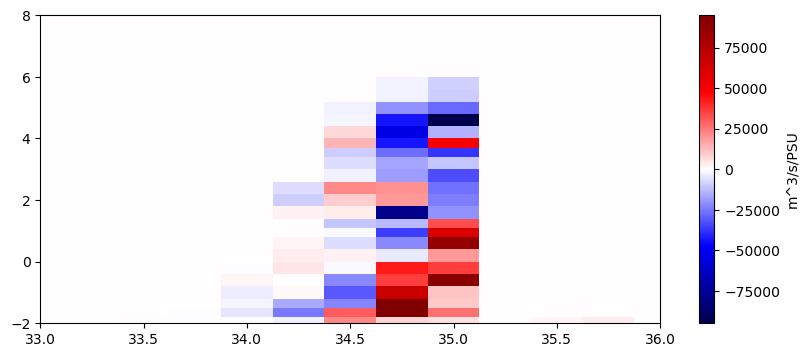

In [220]:
plt.pcolormesh(Sbin2,Tbin2,G_TS.T,cmap='seismic',vmin = np.nanmin(G_TS),vmax = -np.nanmin(G_TS))
plt.colorbar(label="m^3/s/PSU")
plt.xlim(33,36)
plt.ylim(-2,8)

Text(0.5, 1.0, 'resid')

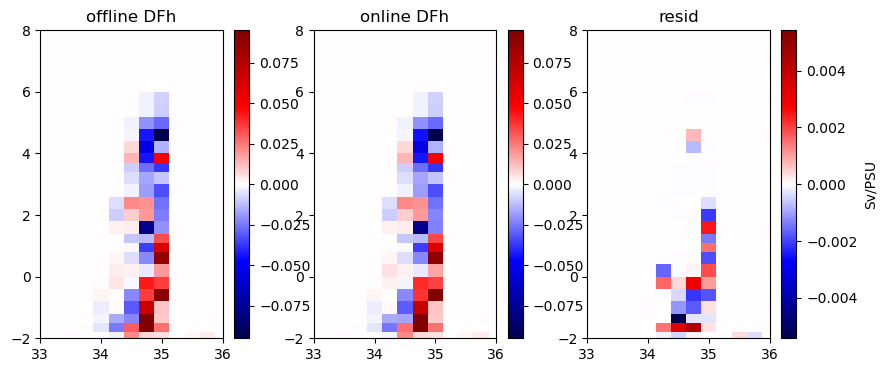

In [221]:
# Is this the same thing? make a figure
DFoff = G_TS.T * 1e-6
DFon = Jy[nbasin][tsstr[1]]['LaTh_TS'].T
resid = DFoff-DFon

fig = plt.figure()

ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin2,Tbin2,DFoff,cmap='seismic',vmin = np.nanmin(DFoff),vmax = -np.nanmin(DFoff))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("offline DFh")

ax = plt.subplot(132)
cb = ax.pcolormesh(Sbin2,Tbin2,DFon,cmap='seismic',vmin = np.nanmin(DFon),vmax = -np.nanmin(DFon))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("online DFh")

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin2,Tbin2,resid,cmap='seismic',vmin = np.nanmin(resid),vmax = -np.nanmin(resid))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("resid")

## this is wrong, but we can load the Jx here to make sure we have it available.

In [20]:
setTS_Stend

['LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS', 'LSto_TS']

In [22]:
# I think we need to redefine J with a single cell or a very small mask (maybe one cell)
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
Jx = {}
Jx[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny,nx)

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jx[nbasin][t] = {}
    Jx[nbasin][t]['G_S'] = {}

    # loop through the diagnostics
    for i in range(len(setTS_Stend)-1, -1, -1):
        filename = dirlayers + f"layers_TSjoint_Stend_set1.{t}.data"
        tmp = read_float64_skip(filename, LwetC2d*(nS-1)*(nT-1),i)
        tmp = np.reshape(tmp,(nT-1,nS-1,LwetC2d))
        print(tmp.shape)
    
        small = rac2d * hf2d
        tmp = tmp * np.tile(small[np.newaxis,np.newaxis,:], (nT - 1, nS - 1,1)) * ffac
    
        if i == len(setTS_Stend)-1:
            # LSto_TS - total tendency
            residS = tmp
        elif i in {0,1,2,3,4}:
            # LaSs_TS LaSh_TS LaSz_TS LSha_TS LSza_TS LSBh_TS
            # surface, hdiff, vdiff, hADV, vADV, hADV bolus
            residS -= tmp
    
        # use stri_wet, strb is names of basins
        tmp1 = np.nansum(tmp[:,:,iwet_mine],axis=2)   # should be of shape nS-1, nT-1
        # TEST
        # tmp1 = tmp1.T
        thisbinwidthT1 = np.tile(binwidthT1[:,np.newaxis],(1, nS - 1))
        tmp2 = np.nansum(tmp1 * thisbinwidthT1, axis=1)                 # second dim is T because this is S tend
        print(setTS_Stend[i])
        Jx[nbasin][t][setTS_Stend[i]] = tmp1
        Jx[nbasin][t]['G_S'][setTS_Stend[i]] = tmp2
        del tmp
        del tmp1
        del tmp2

    tmp1 = np.nansum(residS[:,:,iwet_mine],axis=2)    # sum over geo space
    mytileT1 = np.tile(binwidthT1[np.newaxis,:],(nS-1,1))  # nS-1 x nT-1
    tmp2 = np.nansum(tmp1 * mytileT1, axis=0)     # sum over T ( dimension 0)
    Jx[nbasin][t]["residS"] = tmp1    # should be of shape nS-1, nT-1
    Jx[nbasin][t]["G_S"]["residS"] = tmp2 #should be of shape nT-1

# set units and labels
Jx["descr"] = "m/s/degC"

# # Define your filename
filename = "Jx_miniaste_BarentsS.npz"
matpath = "/scratch2/mmurakami/aste_90x150x60/"
matpath += "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"

# # Save the dictionary
np.savez(matpath + filename, **Jx)

0000000004
(111, 111, 40500)
LSto_TS
(111, 111, 40500)
LSza_TS
(111, 111, 40500)
LSha_TS
(111, 111, 40500)
LaSz_TS
(111, 111, 40500)
LaSh_TS
(111, 111, 40500)
LaSs_TS


In [102]:
# read in TOTTTEND from budg3d_kpptend_set1.0000000003.meta

# load the tend from the get_Jterms and plot this
file_name = 'budg3d_kpptend_set1'
meta_budg3d_kpptend_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_kpptend_set1["fldList"])
varnames = np.array(["TOTTTEND"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])


TOTTTEND,its,meta = rdmds(os.path.join(dirdiags, file_name),int(tsstr[1]),returnmeta=True,rec=recs[0])
TOTTTEND = TOTTTEND.reshape(nz,ny,nx)

In [121]:
Jy[nbasin][tsstr[1]]['LTto_TS']  # this is the total T tend in TS space

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [111]:
TOTTTEND.shape

(50, 450, 90)

In [117]:
# we need to make an array of 111,111 (see next line) which is DFhT_offline binned by cell center
# this is first in units of degC.m^3/s so we need to divide by binwidthT1 and binwidthS1
dF_TS = np.zeros((nT-1, nS-1), dtype=float)
G_TS  = np.zeros((nT-1, nS-1), dtype=float)
L_TS  = np.zeros((nT-1, nS-1), dtype=int)

# Flatten so we don't have to loop thorugh zyx
T_flat   = np.ravel(THETA * mymsk3d, order="F")
S_flat   = np.ravel(SALT  * mymsk3d, order="F")
TOTTTEND_flat = np.ravel(TOTTTEND  * mymsk3d, order="F")
TOTTTEND_flat = np.ravel(TTEND_fromTHETADR  * mymsk3d, order="F")

# 2D binning via bin index lookup (faster than nested np.where) as in previous loop (in create_aste90_layers.py)
iT = np.searchsorted(binmidT, T_flat, side="right") - 1
iS = np.searchsorted(binmidS, S_flat, side="right") - 1

# Keep only points that land in a valid interior bin
ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(TOTTTEND_flat)
iT = iT[ok]
iS = iS[ok]
vals = TOTTTEND_flat[ok]

# Accumulate sums and counts into (T,S) bins
np.add.at(dF_TS, (iT, iS), vals)
np.add.at(L_TS,  (iT, iS), 1)

# Normalize by BOTH bin widths (outer product gives (nT-1, nS-1))
dA = binwidthT1[:, None] * binwidthS1[None, :]
G_TS = dF_TS / dA    # gives units of m^3/s/PSU

Text(0.5, 1.0, 'resid')

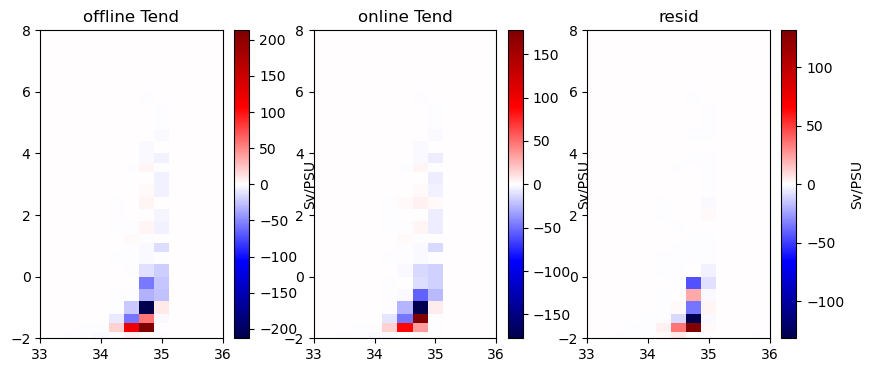

In [120]:
# Is this the same thing? make a figure
TTENDoff = G_TS.T * 1e-6
TTENDon = Jy[nbasin][tsstr[1]]['LTto_TS'].T
resid = TTENDoff-TTENDon

fig = plt.figure()

ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin2,Tbin2,TTENDoff,cmap='seismic',vmin = np.nanmin(TTENDoff),vmax = -np.nanmin(TTENDoff))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("offline Tend")

ax = plt.subplot(132)
cb = ax.pcolormesh(Sbin2,Tbin2,TTENDon,cmap='seismic',vmin = np.nanmin(TTENDon),vmax = -np.nanmin(TTENDon))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("online Tend")

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin2,Tbin2,resid,cmap='seismic',vmin = np.nanmin(resid),vmax = -np.nanmin(resid))
plt.colorbar(cb, label="Sv/PSU")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
ax.set_title("resid")

In [134]:
t2 = int(tsstr[1])
# 'diags/state_3d_set1'
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [135]:
# this did not work so I want to pick a p
TOTTTEND_faces = get_aste_faces(TOTTTEND,nfx,nfy)
THETA_faces = get_aste_faces(THETA,nfx,nfy)

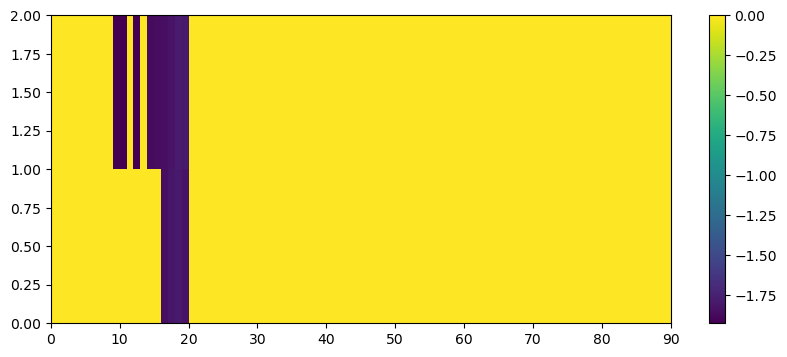

In [139]:
TOTTTEND_faces.f3.shape
plt.pcolormesh(THETA_faces.f3[0][:1,:])
# plt.plot(
plt.colorbar()

In [147]:
a = THETA_faces.f3[0][:1,:]
# np.where(a == -1.82381129)


In [150]:
a[0][19]

-1.8238112926483154

In [151]:
THETA_faces.f3[:,0,19]

array([-1.82381129, -1.82459402,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [157]:
boundsT.flatten()[1:-1][1:3]

array([-2.        , -1.60000002])

In [161]:
binwidthT1[1]

0.40000003576278687

In [165]:
binmidT[1:3]

array([-2.20000005, -1.80000001])

In [168]:
TOTTTEND_faces.f3[:,0,19]

array([-6.33785756e-08, -2.01580728e-09,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00])

In [169]:
# TTEND_fromTHETADR  # validate this is the same as before

In [172]:
# Jy[nbasin]

# load in layers_3d_Ttend.....
tmp = read_float64_skip(dirlayers + "layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),11)

In [184]:
rcp = myparms['rcp']
rac = mygrid['RAC']
drf = mygrid['DRF']

In [194]:
iy,ix = 0,19

rac_f3 = get_aste_faces(rac,nfx,nfy).f3
# drf_f3 = get_aste_faces(drf,nfx,nfy).f3


vol_pt0 = rac_f3[0,0,19]*drf[0]
vol_pt1 = rac_f3[0,0,19]*drf[1]


In [195]:
print(vol_pt0,vol_pt1)

17435507667.868507 17435507667.868507


In [ ]:
# get the indices
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
print(ind.shape)
orig_shape = (ind.shape)
orig_shape = (ind.shape)
mymsk_1d = mymsk2.reshape(orig_shape, order='C')
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

mymsk_1d = mymsk2.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))

# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing


In [181]:
tmp1 = tmp.reshape(nTm1,LwetC2d)

In [196]:
# find out what point we used before in the layers output
# tmptend/binwidth*drf of those gives m/s, which is the same as layers output

# this is not entirely the same as the output but this is due to the difference in precision

In [ ]:
# we can do this exercise on my own and close for this very small bin
# An wonders if the timing of the saving might be off.
# make a template exactly the same way An has done this
# follow through with the same template for Gs and follow through for M for the same 

In [ ]:
# finish doing the J output

# do all the terms in the J equation and highlight these for the very small column
# all of this is on the RHS because 

# I think it would be useful to write out all of the individual terms as components in each of steps of the pkg_layers_doc

# try to get a run through and write out every single one of the terms again.